In [1]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/DMD_context


['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
There are 70 knots
There are: 64 splines
There are: 20 degrees


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/chaosmagpy/model_utils.py:795: UserWarning: Input coordinates include the poles.
  warnings.warn('Input coordinates include the poles.')


['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
C has shape dimensions: (148, 440, 440)


In [2]:
# selecting a set of input modes
mode_numbers = np.arange(1, 63, 1)
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

n = 10

sv_n_list = []

# withdrawing and storing all complex phasors
for mode_num in mode_numbers:
    mode_info_i = Component_Load_SV(mode_num)

    gnm = mode_info_i["gnm"]

    # truncate to 15 and 10
    gnm_n = Truncate_Gauss_Coeffs(gnm, tmax=n)

    # projecting to gridded SV
    A_n_r = Truncate_Gauss_Coeffs(A_15_r, n)
    sv_n = A_n_r @ gnm_n.T

    # appending to list
    sv_n_list.append(sv_n)


In [3]:
corr_n_list = []

for i, mode_num_i in enumerate(mode_numbers):

    phasor_i_n = sv_n_list[i]

    for j, mode_num_j in enumerate(mode_numbers):
        if j > i:

            phasor_j_n = sv_n_list[j]
            
            corr_n = Complex_Phasor_Compare(phasor_i_n, phasor_j_n)

            corr_n_list.append(corr_n)

print(np.percentile(corr_n_list, q=95))

0.5247087134242123


In [8]:
corr_n_list = []

for i, mode_num_i in enumerate(mode_numbers):

    phasor_i_n = sv_n_list[i]

    corr_n_list_sub = []

    for j, mode_num_j in enumerate(mode_numbers):
        if i != j:

            phasor_j_n = sv_n_list[j]
            
            corr_n = Complex_Phasor_Compare(phasor_i_n, phasor_j_n)

            corr_n_list_sub.append(corr_n)

    corr_n_list.append(np.max(corr_n_list_sub))

print(np.percentile(corr_n_list, q=10))

0.501478774564408


(array([ 1.,  1.,  2.,  5.,  8.,  9.,  9., 15.,  8.,  4.]),
 array([0.27951568, 0.34341804, 0.40732039, 0.47122274, 0.5351251 ,
        0.59902745, 0.6629298 , 0.72683216, 0.79073451, 0.85463686,
        0.91853922]),
 <BarContainer object of 10 artists>)

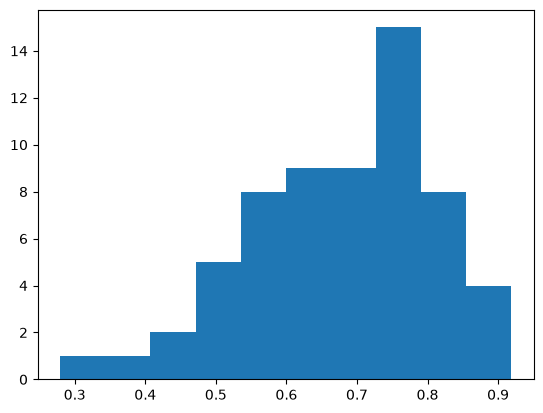

In [13]:
plt.hist(corr_n_list, bins=10)